In [270]:
# import pandas library
import pandas as pd

# read the dataset
df = pd.read_csv("data/81000-0011.csv")
df.head()

,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,81000,National accounts of the Federation,JAHR,Year,2016,DINSG,Germany,DG,Germany,39326.0,1000,ERW061,Employees (domestic concept)
1,81000,National accounts of the Federation,JAHR,Year,2016,DINSG,Germany,DG,Germany,81867.0,1000,BEV020,Population
2,81000,National accounts of the Federation,JAHR,Year,2016,DINSG,Germany,DG,Germany,1630.0,1000,ERW003,Unemployed persons
3,81000,National accounts of the Federation,JAHR,Year,2016,DINSG,Germany,DG,Germany,45243.0,1000,ERW001,Economically active population
4,81000,National accounts of the Federation,JAHR,Year,2016,DINSG,Germany,DG,Germany,43613.0,1000,ERW060,Persons in employment (national concept)


In [271]:
df_emp_popn_ratio = pd.read_csv("data/SLEMPTOTLSPZSDEU.csv")
df_emp_popn_ratio['time'] = pd.to_datetime(df_emp_popn_ratio['observation_date'])
df_emp_popn_ratio['time'] = df_emp_popn_ratio['time'].dt.year
# df_emp_popn_ratio.head()
df_emp_popn_ratio = df_emp_popn_ratio.set_index("time")
df_emp_popn_ratio = df_emp_popn_ratio.sort_index()
df_emp_popn_ratio.head()

,observation_date,SLEMPTOTLSPZSDEU
time,,
1991,1991-01-01,56.430
1992,1992-01-01,55.340
1993,1993-01-01,54.055
1994,1994-01-01,53.562
1995,1995-01-01,53.501


In [272]:
# clean the dataset
columns_to_keep = ['time', 'value', 'value_variable_code']
df = df[columns_to_keep]
df.head()

,time,value,value_variable_code
0,2016,39326.0,ERW061
1,2016,81867.0,BEV020
2,2016,1630.0,ERW003
3,2016,45243.0,ERW001
4,2016,43613.0,ERW060


Our table has a few codes:
We are interested in: 
- BEV020,Population
- ERW060,Persons in employment (national concept)
- ERW001,Economically active population
- ERW003,Unemployed persons
- ERW088,Labour force participation rate

In [273]:
import numpy as np

# set index
df = df.set_index('time')
df.head()

,value,value_variable_code
time,,
2016,39326.0,ERW061
2016,81867.0,BEV020
2016,1630.0,ERW003
2016,45243.0,ERW001
2016,43613.0,ERW060


In [274]:
df = df.sort_index()
df.head()

,value,value_variable_code
time,,
1991,5.3,ERW089
1991,-42.0,PEN012
1991,35352.0,ERW036
1991,38915.0,ERW060
1991,41087.0,ERW001


In [275]:
df = pd.merge(df, df_emp_popn_ratio, on='time', how='inner')
df.head(-5)

,value,value_variable_code,observation_date,SLEMPTOTLSPZSDEU
time,,,,
1991,5.3,ERW089,1991-01-01,56.430
1991,-42.0,PEN012,1991-01-01,56.430
1991,35352.0,ERW036,1991-01-01,56.430
1991,38915.0,ERW060,1991-01-01,56.430
1991,41087.0,ERW001,1991-01-01,56.430
...,...,...,...,...
2025,1652.0,ERW003,2025-01-01,58.323
2025,47482.0,ERW001,2025-01-01,58.323
2025,45830.0,ERW060,2025-01-01,58.323


In [276]:
# Persons in Employment: ERW060 (Employment Level)
employment_level = df[df['value_variable_code'] == "ERW060"]['value']
employment_level = np.array(employment_level).astype(int)
print(employment_level[:5])

[38915 38367 37848 37847 37956]


In [277]:
# Unemployed persons: ERW003
# People who are active seeking for job but do not have one are defined as unemployed.
unemployment_level = df[df['value_variable_code'] == "ERW003"]['value']
unemployment_level = np.array(unemployment_level).astype(int)
print(unemployment_level[:5])

[2172 2573 3050 3306 3205]


In [278]:
# Labor force participation rate: ERW088
# The ratio of total population actively seeking for employment to the total population aged 15+ is defined as the participation rate.
participation_rate = df[df['value_variable_code'] == "ERW088"]['value']
participation_rate = np.array(participation_rate).astype(float)
print("Mean Growth Rate: ", participation_rate.mean().round(2))
print("Highest Growth Rate: ", participation_rate.max().round(2))
print("Lowest Growth Rate: ", participation_rate.min().round(2))
print("Standard Deviation: ", participation_rate.std().round(2))

Mean Growth Rate:  53.91
Highest Growth Rate:  56.8
Lowest Growth Rate:  50.5
Standard Deviation:  2.07


In [279]:
# Civilian Employment - Population Ratio 
# The ratio of employed to the population aged 15+ is Civilian Emp - Popn Ratio.
emp_pop_ratio = df[:]['SLEMPTOTLSPZSDEU'].astype(float)
emp_pop_ratio = emp_pop_ratio[~emp_pop_ratio.index.duplicated(keep='first')]
emp_pop_ratio = np.array(emp_pop_ratio).astype(float) / 100
print((emp_pop_ratio))

[0.5643  0.5534  0.54055 0.53562 0.53501 0.52893 0.5249  0.5248  0.53171
 0.53398 0.53398 0.52888 0.5219  0.51294 0.51803 0.52934 0.53907 0.54651
 0.54545 0.55134 0.56282 0.56737 0.57074 0.57371 0.57442 0.57932 0.58366
 0.588   0.59368 0.58131 0.58224 0.58926 0.59175 0.58849 0.58323]


In [299]:
# Civilian Working Age Population
# = Persons employed / (Person Employed / Working Age Population)
civ_working_pop = employment_level / emp_pop_ratio
print("Mean Growth Rate: ", civ_working_pop.mean())
print("Highest Growth Rate: ", civ_working_pop.max())
print("Lowest Growth Rate: ", civ_working_pop.min())
print("Standard Deviation: ", civ_working_pop.std())

Mean Growth Rate:  74422.87856336021
Highest Growth Rate:  78579.63410661317
Lowest Growth Rate:  68961.54527733475
Standard Deviation:  2338.741943968711


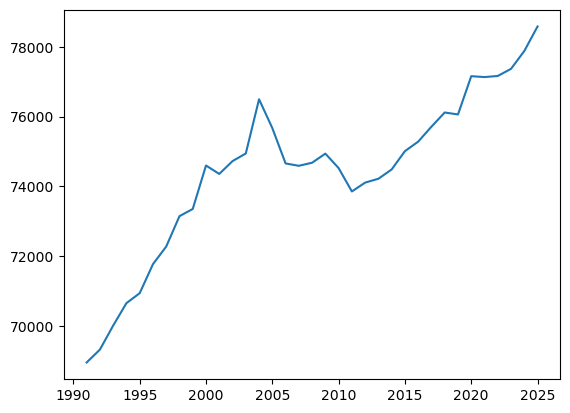

In [281]:
# Graph for Civilian Working Age Population
import matplotlib.pyplot as plt

plt.plot(range(1991,2026), civ_working_pop)

In [282]:
civ_working_gr = (np.diff(civ_working_pop) / civ_working_pop[:-1]) * 100
civ_working_gr[:5]
print("Mean Growth Rate: ", civ_working_gr.mean().round(2))
print("Highest Growth Rate: ", civ_working_gr.max().round(2))
print("Lowest Growth Rate: ", civ_working_gr.min().round(2))
print("Standard Deviation: ", civ_working_gr.std().round(2))

Mean Growth Rate:  0.39
Highest Growth Rate:  2.07
Lowest Growth Rate:  -1.34
Standard Deviation:  0.71


Text(0.5, 1.0, 'Computed Civilian Working Age Population, Germany (1991-2025)')

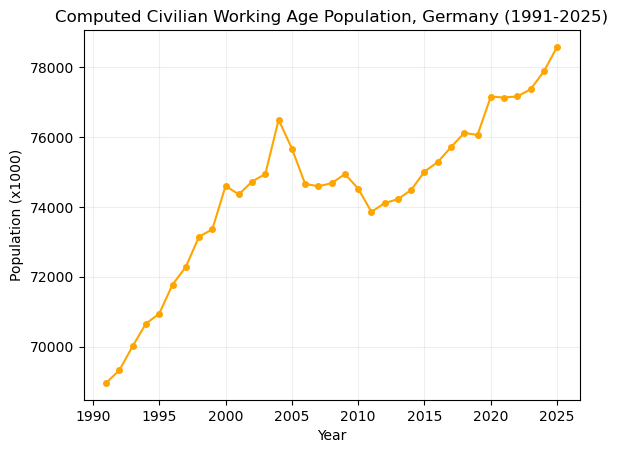

In [283]:
# Part 2.2: Plot the Civilian Working Population in a Graph
plt.plot(range(1991, 2026), civ_working_pop, color="orange", label="Population (1000s)", marker="o", markersize="4")
plt.xlabel(xlabel="Year")
plt.ylabel(ylabel="Population (x1000)")
plt.grid(alpha=0.2)
plt.title("Computed Civilian Working Age Population, Germany (1991-2025)")

In [284]:
labor_force = employment_level + unemployment_level
labor_force[:5]
print("Mean Growth Rate: ", labor_force.mean())
print("Highest Growth Rate: ", labor_force.max())
print("Lowest Growth Rate: ", labor_force.min())
print("Standard Deviation: ", labor_force.std())

Mean Growth Rate:  43913.485714285714
Highest Growth Rate:  47482
Lowest Growth Rate:  40898
Standard Deviation:  1969.601894095477


In [285]:
# Part 2.3: Participation Rate = (Labor Force: Employment Level + Unemployment Level) / (Working Age Population)
participation_rate_computed = (labor_force / civ_working_pop * 100)
participation_rate_computed[:5]
print("Mean Growth Rate: ", participation_rate_computed.mean().round(2))
print("Highest Growth Rate: ", participation_rate_computed.max().round(2))
print("Lowest Growth Rate: ", participation_rate_computed.min().round(2))
print("Standard Deviation: ", participation_rate_computed.std().round(2))

Mean Growth Rate:  58.99
Highest Growth Rate:  61.01
Lowest Growth Rate:  56.69
Standard Deviation:  1.23


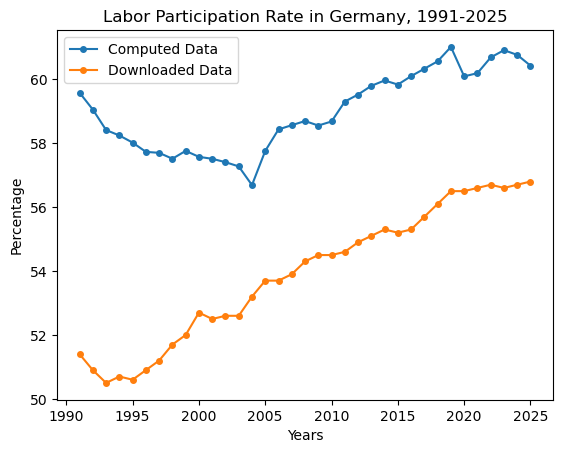

In [286]:
plt.plot(range(1991,2026), participation_rate_computed, label="Computed Data", marker="o", markersize="4")
plt.plot(range(1991,2026), participation_rate, label="Downloaded Data", marker="o", markersize="4")
plt.xlabel(xlabel="Years")
plt.ylabel(ylabel="Percentage")
plt.title("Labor Participation Rate in Germany, 1991-2025")
plt.legend()

In [287]:
# Employment Rate
employment_rate = employment_level / civ_working_pop * 100
print("Mean Growth Rate: ", employment_rate.mean().round(2))
print("Highest Growth Rate: ", employment_rate.max().round(2))
print("Lowest Growth Rate: ", employment_rate.min().round(2))
print("Standard Deviation: ", employment_rate.std().round(2))

Mean Growth Rate:  55.46
Highest Growth Rate:  59.37
Lowest Growth Rate:  51.29
Standard Deviation:  2.51


In [288]:
# Unemployment Rate
unemployment_rate = unemployment_level / labor_force * 100
print("Mean Growth Rate: ", unemployment_rate.mean().round(2))
print("Highest Growth Rate: ", unemployment_rate.max().round(2))
print("Lowest Growth Rate: ", unemployment_rate.min().round(2))
print("Standard Deviation: ", unemployment_rate.std().round(2))

Mean Growth Rate:  6.03
Highest Growth Rate:  10.31
Lowest Growth Rate:  2.69
Standard Deviation:  2.35


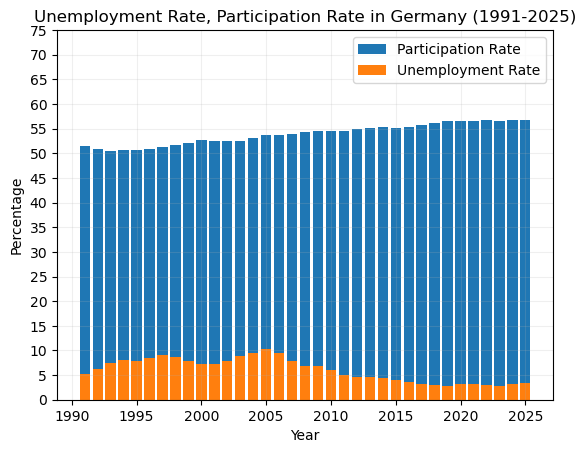

In [289]:
plt.bar(range(1991, 2026), participation_rate, label="Participation Rate",)
plt.bar(range(1991, 2026), unemployment_rate, label="Unemployment Rate",)
plt.yticks(range(0,80,5))
plt.xlabel(xlabel="Year")
plt.grid(alpha=0.2)
plt.ylabel(ylabel="Percentage")
plt.title("Unemployment Rate, Participation Rate in Germany (1991-2025)")
plt.legend()

In [294]:
employment_growth = (np.diff(employment_level)/employment_level[:-1] * 100) 
unemployment_growth = (np.diff(unemployment_level)/unemployment_level[:-1] * 100)

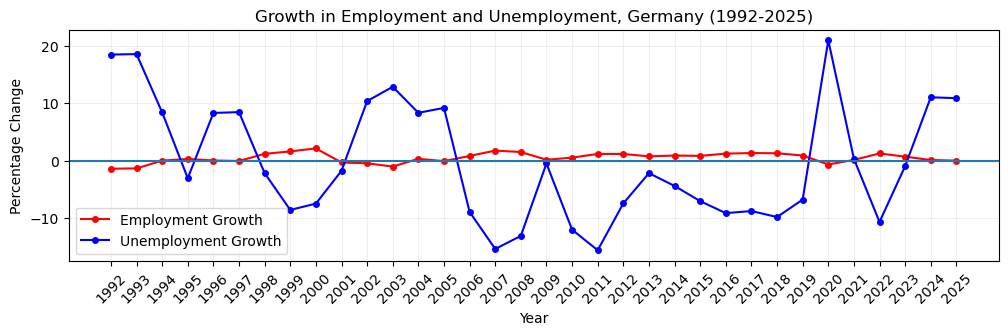

In [364]:
plt.figure(figsize=(12, 3))
years = np.arange(1992, 2026)
plt.plot(years, employment_growth, color="red", label="Employment Growth", marker="o", markersize="4")
plt.plot(years, unemployment_growth, color="blue", label="Unemployment Growth", marker="o", markersize="4")
plt.grid(alpha=0.2)
plt.xlabel(xlabel="Year")
plt.ylabel(ylabel="Percentage Change")
plt.axhline(y=0)
plt.xticks(years, rotation=45)
plt.title("Growth in Employment and Unemployment, Germany (1992-2025)")
plt.legend()

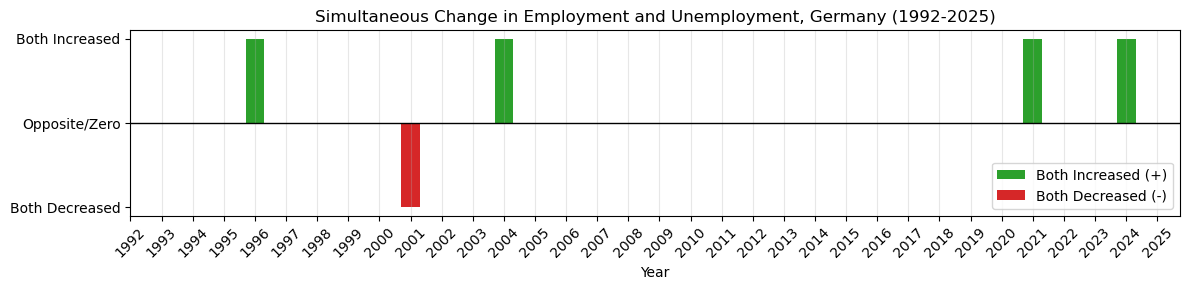

In [363]:
# Both Increased/Decreased
years = np.arange(1992, 2026)
both_increase = (employment_growth > 0) & (unemployment_growth > 0)
both_decrease = (employment_growth < 0) & (unemployment_growth < 0)
# 3. Plot the Boolean Bar Plot
plt.figure(figsize=(12, 3))

# Plot +1 for simultaneous increase, -1 for simultaneous decrease
plt.bar(years[both_increase], 1, color='tab:green', label='Both Increased (+)', width=0.6)
plt.bar(years[both_decrease], -1, color='tab:red', label='Both Decreased (-)', width=0.6)

# Formatting
plt.axhline(0, color='black', linewidth=1)
plt.yticks([-1, 0, 1], ['Both Decreased', 'Opposite/Zero', 'Both Increased'])
plt.xlabel("Year")
plt.legend(loc="lower right")
plt.grid(axis='x', alpha=0.3)
plt.xticks(years, rotation=45)
plt.title("Simultaneous Change in Employment and Unemployment, Germany (1992-2025)")

plt.tight_layout()

plt.show()